## Sample code for SINDy (van der Pol oscillator)

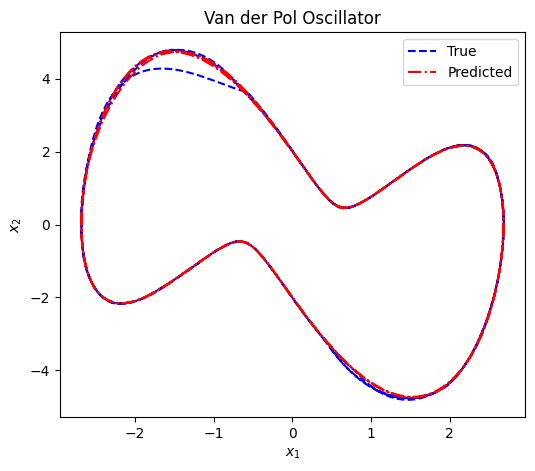

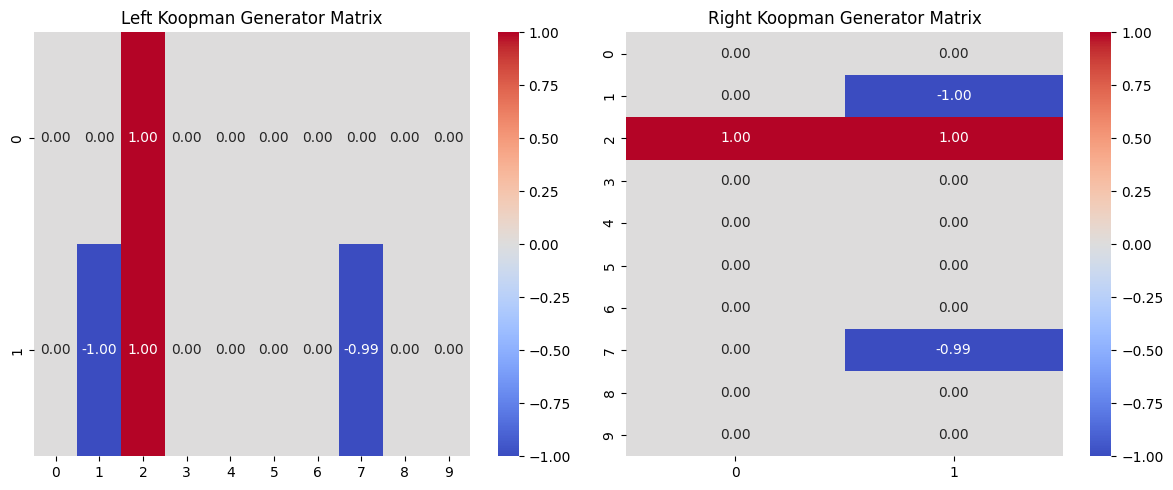

In [1]:
%matplotlib inline
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt # If you don't have matplotlib, you can install it via pip: pip install matplotlib
import seaborn as sns           # If you don't have seaborn, you can install it via pip: pip install seaborn
from ddsm.dicts import MonomialsDict
from ddsm.estimators import SINDy


def van_der_Pol(t, z, mu = 1.0):
    x, y = z
    dxdt = y
    dydt = mu * (1 - x**2) * y - x
    return [dxdt, dydt]

dt = 1.0e-3
sol = solve_ivp(
    fun=van_der_Pol,
    t_span=[0, 20],
    y0=[2.0, 0.0],
    t_eval=np.arange(0, 20 + dt, dt)
)

# Prepare data (n_samples, n_features)
x = sol.y[:, :-1].T
y = sol.y[:, 1:].T
dx = (y - x) / dt

# Create estimator (with monomials up to degree 3, threshold=0.01 and max_iter=1000)
estimator = SINDy(
    psi_cls=MonomialsDict,
    psi_kwargs={'degree': 3},
    threshold=0.1,
    max_iter=20
)

# Fit the estimator to the data
estimator.fit(x, dx)

# Predict the next state
dx_pred = estimator.predict(x)

# Plot the results
plt.figure(figsize=(6, 5))
plt.plot(dx[:, 0], dx[:, 1], label='True', color='blue', linestyle='--')
plt.plot(dx_pred[:, 0], dx_pred[:, 1], label='Predicted', color='red', linestyle='-.')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend()
plt.title('Van der Pol Oscillator')
plt.show()

# Access the Koopman generator matrix
## If you want to access the left Koopman generator matrix
left_L = estimator.left_L

## If you want to access the right Koopman generator matrix
right_L = estimator.right_L

# Plot the Koopman generator matrices
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(left_L, annot=True, vmin=-1.0, vmax=1.0, fmt='.2f', cmap='coolwarm')
plt.title('Left Koopman Generator Matrix')
plt.subplot(1, 2, 2)
sns.heatmap(right_L, annot=True, vmin=-1.0, vmax=1.0, fmt='.2f', cmap='coolwarm')
plt.title('Right Koopman Generator Matrix')
plt.tight_layout()
plt.show()